In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv('house_prices_practice.csv')
print(df.isnull().sum())

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


In [9]:
df=df.drop('Id', axis=1)

In [10]:
n=df[['OverallQual','GrLivArea','GarageCars']].values
m=df['SalePrice'].values
m=m.reshape(-1,1)

In [11]:
mean=np.mean(n,axis=0)
std=np.std(n,axis=0)
n_scalled=(n-mean)/std

In [12]:
n_squared=n_scalled**2
n_poly=np.hstack((n_scalled,n_squared))
n_new=np.hstack((np.ones((len(n_poly),1)),n_poly))

In [13]:
w=np.random.rand(7,1)

In [14]:
cost_history=[]
for i in range(1000):
  h=n_new @ w
  E=h-m
  cost=(1/(2*len(n_scalled)))*np.sum(np.square(E))
  cost_history.append(cost)
  w= w-((0.001/len(n_scalled))*n_new.T@E)
print('complete trainig!')

complete trainig!


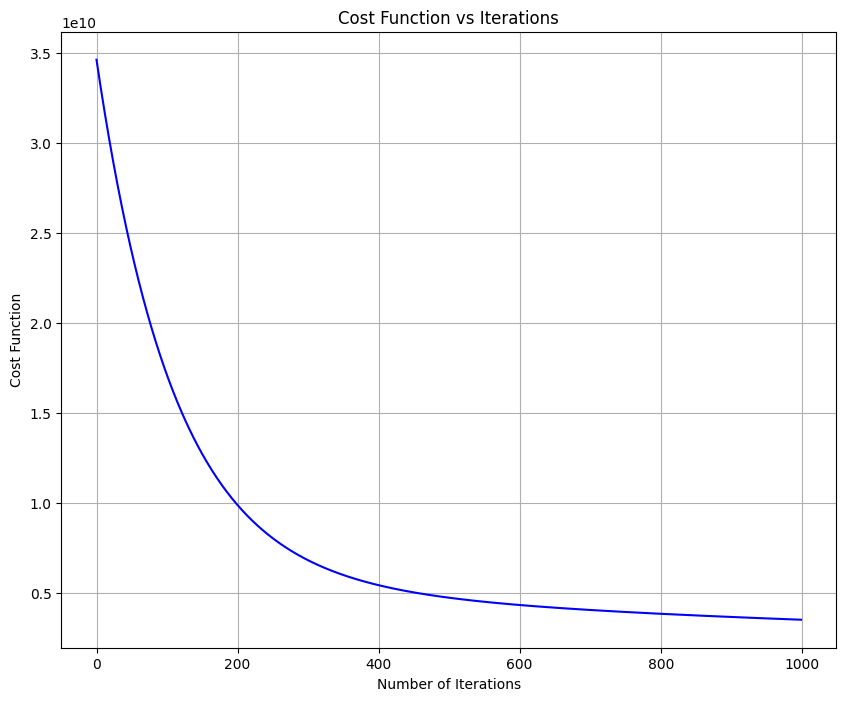

In [15]:
plt.figure(figsize=(10,8))
plt.plot(range(1000),cost_history,color='blue')
plt.title('Cost Function vs Iterations')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost Function')
plt.grid(True)
plt.show()